In [1]:
import pandas as pd
import numpy as np


### Uploading the dataset to perfrom the data analysis


In [7]:
df=pd.read_excel('Housing.xlsx')

In [4]:
df.tail(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
535,2100000,3360,2,1,1,yes,no,no,no,no,1,no,unfurnished
536,1960000,3420,5,1,2,no,no,no,no,no,0,no,unfurnished
537,1890000,1700,3,1,2,yes,no,no,no,no,0,no,unfurnished
538,1890000,3649,2,1,1,yes,no,no,no,no,0,no,unfurnished
539,1855000,2990,2,1,1,no,no,no,no,no,1,no,unfurnished
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished
544,1750000,3850,3,1,2,yes,no,no,no,no,0,no,unfurnished


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.describe

<bound method NDFrame.describe of         price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0    13300000  7420         4          2        3      yes        no       no   
1    12250000  8960         4          4        4      yes        no       no   
2    12250000  9960         3          2        2      yes        no      yes   
3    12215000  7500         4          2        2      yes        no      yes   
4    11410000  7420         4          1        2      yes       yes      yes   
..        ...   ...       ...        ...      ...      ...       ...      ...   
540   1820000  3000         2          1        1      yes        no      yes   
541   1767150  2400         3          1        1       no        no       no   
542   1750000  3620         2          1        1      yes        no       no   
543   1750000  2910         3          1        1       no        no       no   
544   1750000  3850         3          1        2      yes        no       no   

    hotwaterheating airconditioning  parking prefarea furnishingstatus  
0                no             yes        2      yes        furnished  
1                no             yes        3       no        furnished  
2                no              no        2      yes   semi-furnished  
3                no             yes        3      yes        furnished  
4                no             yes        2       no        furnished  
..              ...             ...      ...      ...              ...  
540              no              no        2       no      unfurnished  
541              no              no        0       no   semi-furnished  
542              no              no        0       no      unfurnished  
543              no              no        0       no        furnished  
544              no              no        0       no      unfurnished  

[545 rows x 13 columns]>

### **Here the categorical data is been labeled by doing one hot encoding**

In [8]:
# Perform one-hot encoding on categorical columns
# drop_first=True is used to avoid the dummy variable trap
df_encoded = pd.get_dummies(df, columns=['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus'], drop_first=True)

# Display the first few rows of the encoded dataframe
display(df_encoded.head())

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [10]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Create a copy of the original dataframe for label encoding
df_label = df.copy()

# List of categorical columns
cat_cols = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea', 'furnishingstatus']

# Apply LabelEncoder to each column
for col in cat_cols:
    df_label[col] = le.fit_transform(df_label[col])

# Display the first few rows of the label encoded dataframe
display(df_label.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0


### **Then the correlation matrix has been plotted to understand the relations among the different variables**

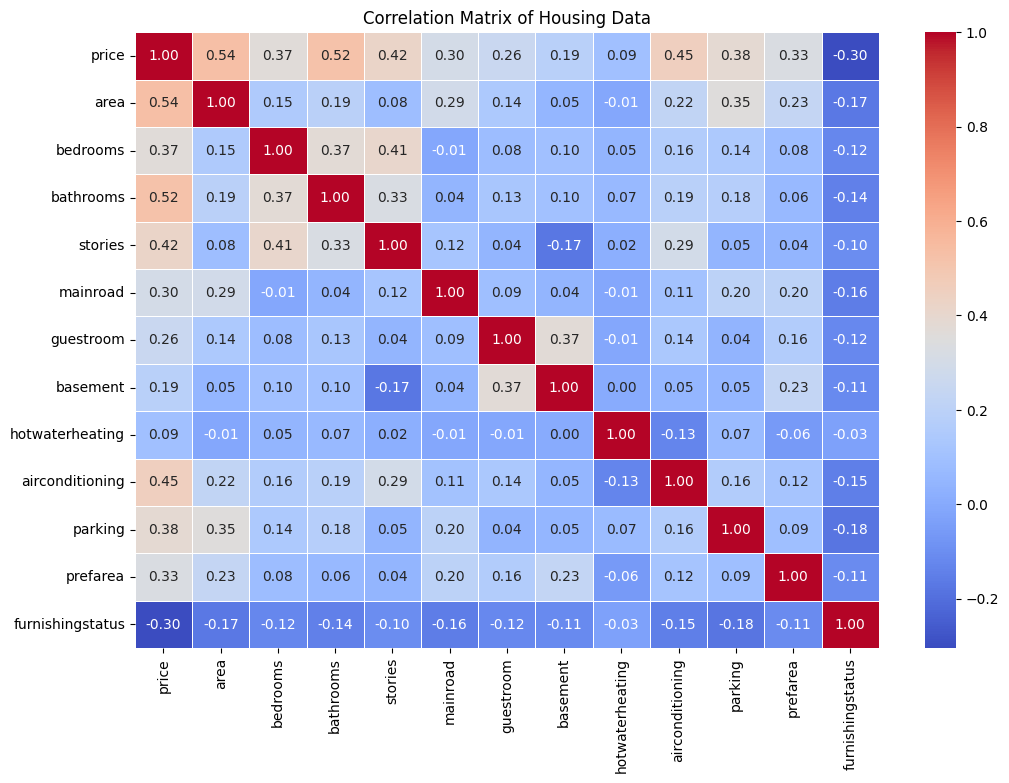

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the correlation matrix using the label-encoded dataframe
corr_matrix = df_label.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 8))

# Draw the heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Matrix of Housing Data')
plt.show()

### Boxplot is further used to identify the outliers in the dataset

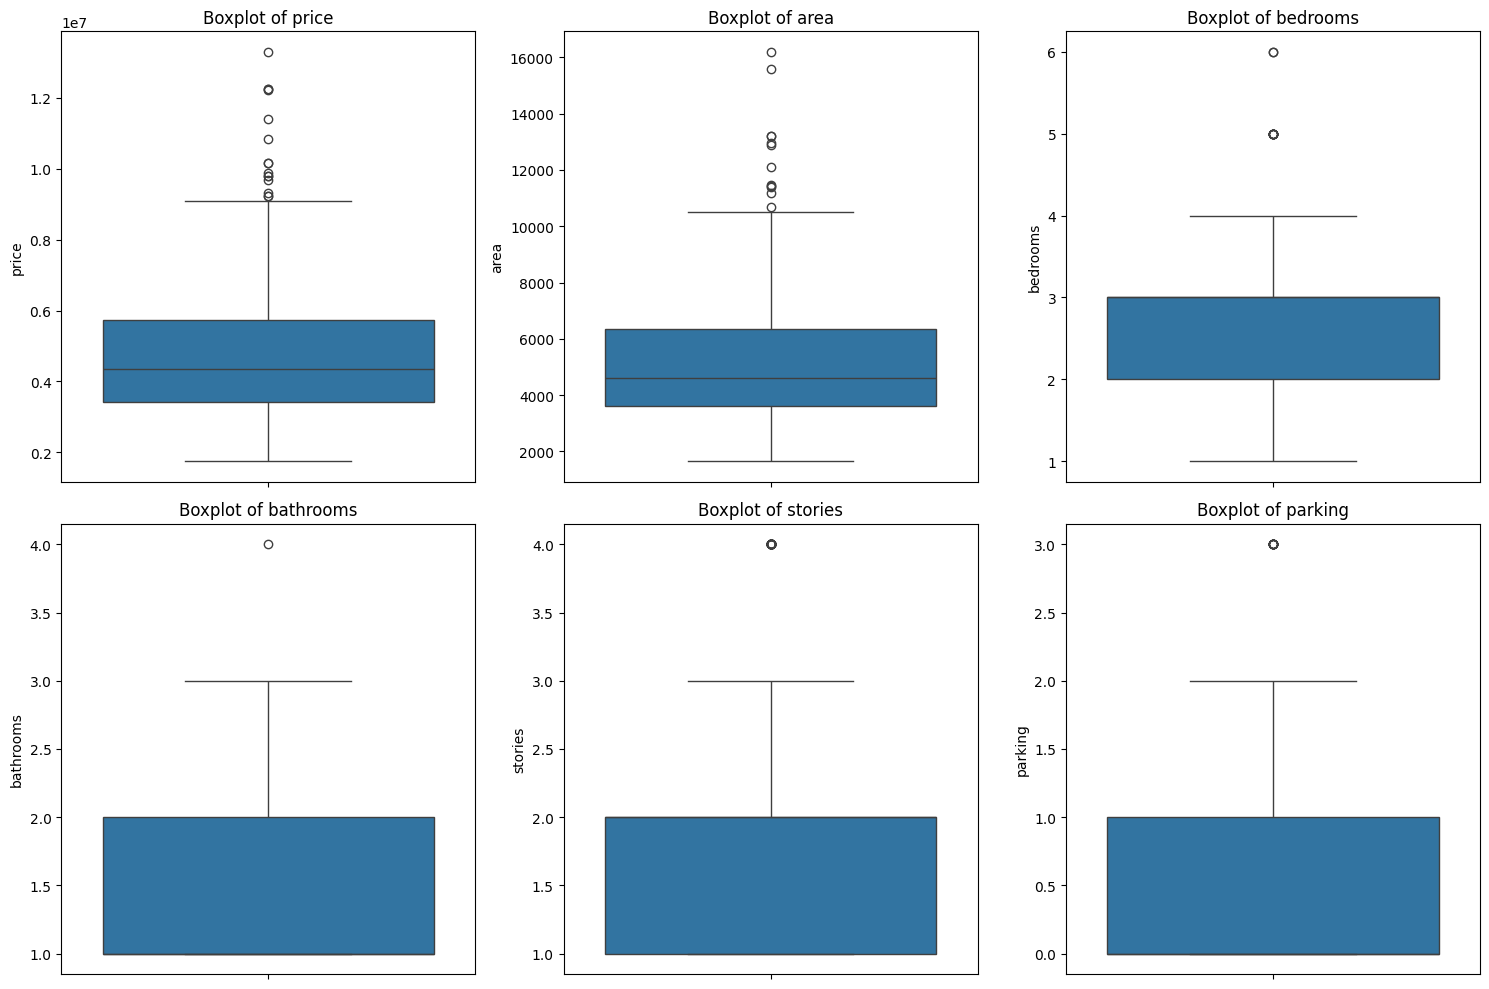

In [12]:
# List of numerical columns to check for outliers
num_cols = ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']

plt.figure(figsize=(15, 10))

# Create subplots for each numerical column
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

### Summary Note on Outliers
Based on the boxplots:
- **Price:** Significant outliers are present at the higher end, indicating luxury properties that are much more expensive than the median house.
- **Area:** There are several data points beyond the upper whisker, suggesting some houses have exceptionally large lot sizes.
- **Bathrooms & Bedrooms:** A few properties show a high number of rooms/bathrooms which, while less frequent, represent larger residential structures.
- **Stories & Parking:** These show discrete distributions with some values reaching the upper limits, but they are less likely to be 'errors' and more likely to be specific property configurations.

### Spliting data into Training and Testing. In 80:20 ratio respectively  

In [13]:
from sklearn.model_selection import train_test_split

# Defining features (X) and target variable (y)
# We'll use the label-encoded dataframe for the model
X = df_label.drop('price', axis=1)
y = df_label['price']

# Splitting the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (436, 12)
Testing set shape: (109, 12)


In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Initialize the Linear Regression model
model = LinearRegression()

# Fit the model on the training data
model.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared Score: {r2:.4f}")

Mean Squared Error: 1771751116594.04
R-squared Score: 0.6495


### **Now we have perfromed the treatment of outliers in our dataset**

In [18]:
# Function to remove outliers based on IQR
def remove_outliers(df, columns):
    df_cleaned = df.copy()
    for col in columns:
        Q1 = df_cleaned[col].quantile(0.25)
        Q3 = df_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df_cleaned = df_cleaned[(df_cleaned[col] >= lower_bound) & (df_cleaned[col] <= upper_bound)]
    return df_cleaned

# Identify numerical columns for outlier removal (Price and Area are the most critical)
columns_to_clean = ['price', 'area']
df_no_outliers = remove_outliers(df_label, columns_to_clean)

print(f"Original dataset size: {len(df_label)}")
print(f"Dataset size after removing outliers: {len(df_no_outliers)}")

Original dataset size: 545
Dataset size after removing outliers: 517


In [19]:
# Retrain the model on cleaned data
X_clean = df_no_outliers.drop('price', axis=1)
y_clean = df_no_outliers['price']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_clean, y_clean, test_size=0.2, random_state=42)

clean_model = LinearRegression()
clean_model.fit(X_train_c, y_train_c)
y_pred_c = clean_model.predict(X_test_c)

# Metrics
mse_c = mean_squared_error(y_test_c, y_pred_c)
r2_c = r2_score(y_test_c, y_pred_c)

print(f"New R-squared Score: {r2_c:.4f}")
print(f"Improvement from previous R2: {r2_c - r2:.4f}")

New R-squared Score: 0.6668
Improvement from previous R2: 0.0173


### **Now we have performed the OLS Regression analysis**

In [20]:
import statsmodels.api as sm

# Adding a constant to the features (X) for the intercept term
X_train_sm = sm.add_constant(X_train_c)

# Fit the regression model using statsmodels
sm_model = sm.OLS(y_train_c, X_train_sm).fit()

# Display the summary table
print(sm_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.657
Model:                            OLS   Adj. R-squared:                  0.646
Method:                 Least Squares   F-statistic:                     63.71
Date:                Tue, 05 May 2026   Prob (F-statistic):           5.42e-85
Time:                        03:21:31   Log-Likelihood:                -6254.8
No. Observations:                 413   AIC:                         1.254e+04
Df Residuals:                     400   BIC:                         1.259e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             4.241e+05   2.65e+05  

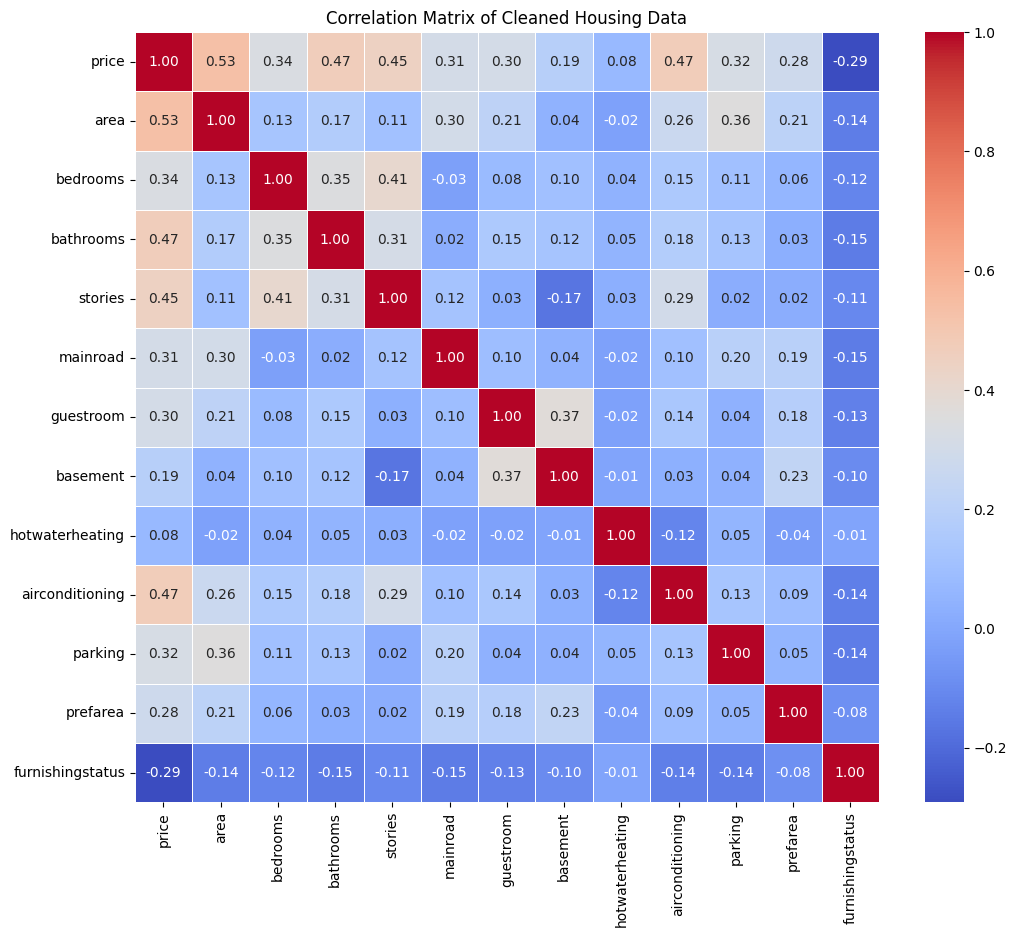

In [21]:
# Calculate correlation matrix for the cleaned dataset
corr_matrix_clean = df_no_outliers.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_clean, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Cleaned Housing Data')
plt.show()

### **Here we identify the distribution of residuals in our data**

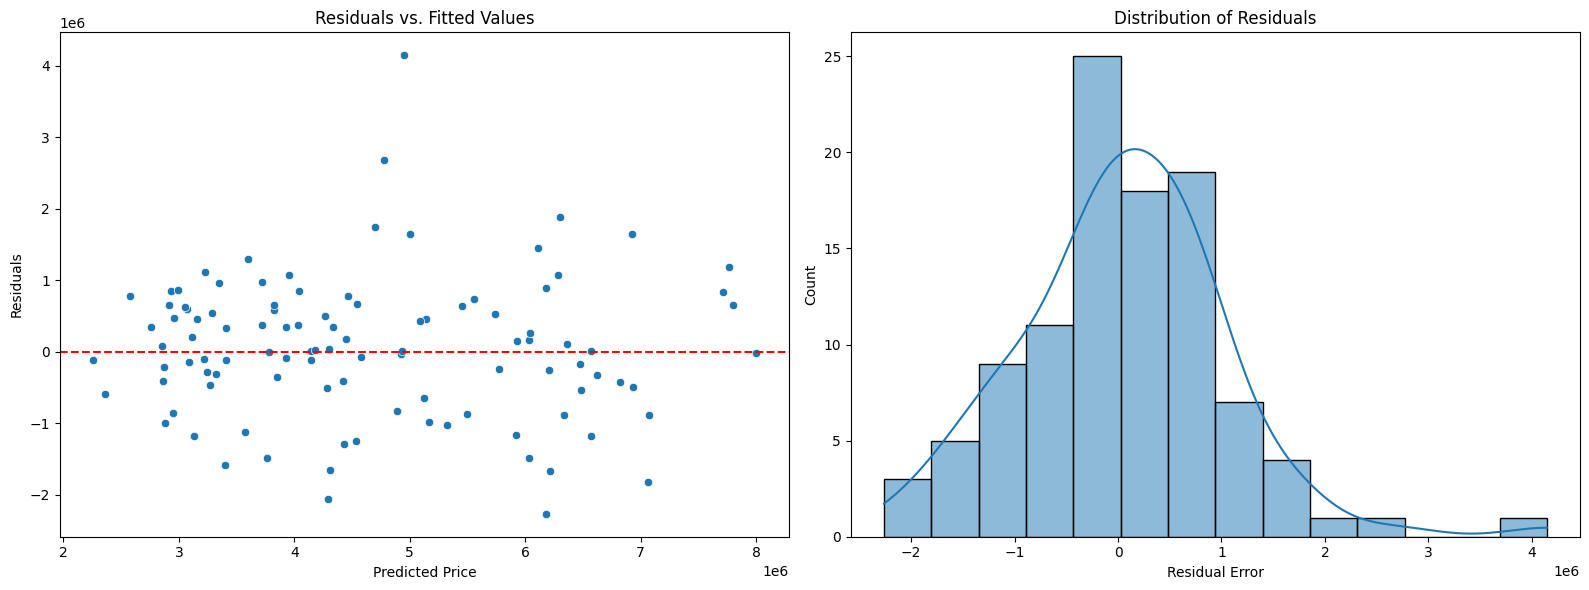

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate residuals
residuals = y_test_c - y_pred_c

# Create a figure with two subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residuals vs Fitted values
sns.scatterplot(x=y_pred_c, y=residuals, ax=ax[0])
ax[0].axhline(y=0, color='r', linestyle='--')
ax[0].set_title('Residuals vs. Fitted Values')
ax[0].set_xlabel('Predicted Price')
ax[0].set_ylabel('Residuals')

# 2. Distribution of residuals
sns.histplot(residuals, kde=True, ax=ax[1])
ax[1].set_title('Distribution of Residuals')
ax[1].set_xlabel('Residual Error')

plt.tight_layout()
plt.show()

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Selecting the independent variables from the cleaned dataset (excluding price)
X_vif = df_no_outliers.drop('price', axis=1)

# Adding a constant for VIF calculation
X_vif_const = sm.add_constant(X_vif)

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif_const.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif_const.values, i) for i in range(X_vif_const.shape[1])]

# Display VIF values sorted
display(vif_data.sort_values(by='VIF', ascending=False))

,Feature,VIF
0,const,34.837017
4,stories,1.468864
1,area,1.379306
2,bedrooms,1.341869
7,basement,1.317300
3,bathrooms,1.254088
6,guestroom,1.250556
9,airconditioning,1.208263
10,parking,1.193827
5,mainroad,1.180753


### Comprehensive Summary of Performed Steps

1.  **Data Loading & Initial Inspection**:
    *   Imported the `Housing.xlsx` dataset using `pandas`.
    *   Inspected the data structure using `.tail()`, `.info()`, and `.describe` to understand column types and identify potential issues.

2.  **Categorical Data Preprocessing**:
    *   **One-Hot Encoding**: Created binary flags for categorical columns using `pd.get_dummies`.
    *   **Label Encoding**: Transformed categorical strings into integers using `LabelEncoder` to facilitate correlation analysis and modeling.

3.  **Exploratory Data Analysis (EDA)**:
    *   **Correlation Heatmap**: Visualized relationships between all features and the target variable (`price`).
    *   **Outlier Detection**: Generated boxplots for numerical columns, identifying significant outliers in `price` and `area`.

4.  **Outlier Management**:
    *   Implemented an **Interquartile Range (IQR) filter** function to remove extreme values.
    *   Cleaned the dataset by removing outliers in `price` and `area`, reducing the count from 545 to 517 samples.

5.  **Baseline Modeling (Scikit-Learn)**:
    *   Split the data into training (80%) and testing (20%) sets.
    *   Trained a **Multiple Linear Regression** model, achieving an $R^2$ of ~0.6495.

6.  **Model Refinement & Statistical Analysis**:
    *   Retrained the model on the cleaned dataset, improving the $R^2$ to **0.6668**.
    *   Used `statsmodels` to generate a detailed summary, identifying statistically significant predictors (e.g., `bathrooms`, `airconditioning`) and insignificant ones (e.g., `bedrooms`).

7.  **Diagnostic Checks**:
    *   **Residual Analysis**: Created scatter plots and histograms of residuals to check for linearity and normality. Observed some heteroscedasticity at higher price points.
    *   **Multicollinearity Check (VIF)**: Calculated Variance Inflation Factors for all features. All values were < 2.0, confirming that multicollinearity is not an issue.